# 약물 수요 예측 프로젝트 - Step 2: 전처리
**목표**: 원본 엑셀(멀티헤더 Wide 형식) → 모델링 투입 가능한 tidy 마스터 데이터셋 생성  
**출력**: `output/data/` 하위 CSV 파일들

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'dataset'
OUT_DATA = 'output/data'
OUT_FIG  = 'output/figures'
os.makedirs(OUT_DATA, exist_ok=True)
os.makedirs(OUT_FIG,  exist_ok=True)

print('환경 설정 완료')

환경 설정 완료


## 1. 파싱 함수 정의

In [2]:
# 역할: ATC 시군구별 엑셀 파일을 읽어서 분석 가능한 형태로 변환
# 원본 엑셀은 Wide 형식 (열이 기간별로 옆으로 펼쳐진 구조)인데, 이를 Long 형식 (한 행 = 한 구 × 한 달)으로
# atc_name으로 'A10A' 또는 'A10B'를 넘겨서 어떤 약물인지 레이블링
def parse_atc_sigungu(filepath, atc_name):
    """ATC 시군구별 엑셀(멀티헤더 Wide) → Long DataFrame"""
    df_raw = pd.read_excel(filepath, header=None)
    period_row = df_raw.iloc[2].tolist()
    header_row = df_raw.iloc[3].tolist()

    col_pairs = []
    current_period = None
    i = 4
    while i < len(period_row):
        val = period_row[i]
        if isinstance(val, str) and '년' in val:
            current_period = val.strip()
        if current_period and isinstance(header_row[i], str) and '수량' in header_row[i]:
            col_pairs.append((current_period, i, i + 1))
        i += 1

    df_data = df_raw.iloc[4:].copy()
    df_data = df_data[df_data.iloc[:, 0] != '계'].reset_index(drop=True)

    records = []
    for period, qty_idx, amt_idx in col_pairs:
        temp = pd.DataFrame()
        temp['ATC코드']    = df_data.iloc[:, 0]
        temp['ATC코드명']  = df_data.iloc[:, 1]
        temp['시도명칭']   = df_data.iloc[:, 2]
        temp['시군구명칭'] = df_data.iloc[:, 3]
        temp['기간']       = period
        temp['수량'] = pd.to_numeric(df_data.iloc[:, qty_idx], errors='coerce')
        temp['금액'] = pd.to_numeric(df_data.iloc[:, amt_idx], errors='coerce')
        records.append(temp)

    df = pd.concat(records, ignore_index=True)
    df['기간_dt'] = pd.to_datetime(
        df['기간'].str.replace('년 ', '-').str.replace('월', ''), format='%Y-%m'
    )
    df['약물구분'] = atc_name
    df = df.dropna(subset=['수량']).reset_index(drop=True)
    return df

# 주민등록 인구 파일에서 구(區) 단위 데이터만 추출
#구명칭을 추출해서, 처방 데이터와 join할 수 있는 키를 만들기 위함
def parse_population():
    """주민등록 인구 - 구 단위만 추출"""
    df_raw = pd.read_excel(
        f'{DATA_DIR}/202510_202510_주민등록인구및세대현황_월간.xlsx', header=None
    )
    df = df_raw.iloc[2:].copy()
    df.columns = ['행정기관코드','행정기관','총거주자수','세대수',
                  '세대당인구','남자인구수','여자인구수','남여비율']
    df = df.reset_index(drop=True)
    for col in ['총거주자수','세대수','세대당인구','남자인구수','여자인구수','남여비율']:
        df[col] = df[col].astype(str).str.replace(',','').pipe(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=['총거주자수'])
    df = df[(df['행정기관코드'].astype(str).str.len() == 10) &
             (~df['행정기관코드'].astype(str).str.endswith('00000000'))].copy()
    df['시군구명칭'] = df['행정기관'].str.split().str[-1]
    return df

# 연령별 인구 파일에서 구 단위 데이터 추출 + 고령인구비율 계산
# 60세 이상 연령대 합산
def parse_age_population():
    """연령별 인구 - 구 단위만 추출"""
    df_raw = pd.read_excel(
        f'{DATA_DIR}/202510_202510_연령별인구현황_월간.xlsx', header=None
    )
    df = df_raw.iloc[4:].copy().reset_index(drop=True)
    df.columns = range(len(df.columns))

    age_labels = ['0~9세','10~19세','20~29세','30~39세','40~49세',
                  '50~59세','60~69세','70~79세','80~89세','90~99세','100세이상']
    result = pd.DataFrame()
    result['행정기관코드'] = df.iloc[:, 0]
    result['행정기관']    = df.iloc[:, 1]
    result['총거주자수']  = df.iloc[:, 2].astype(str).str.replace(',','').pipe(pd.to_numeric, errors='coerce')
    for i, label in enumerate(age_labels):
        result[label] = df.iloc[:, 4 + i].astype(str).str.replace(',','').pipe(pd.to_numeric, errors='coerce')

    result = result.dropna(subset=['총거주자수'])
    result = result[(result['행정기관코드'].astype(str).str.len() == 10) &
                   (~result['행정기관코드'].astype(str).str.endswith('00000000'))].copy()
    result['시군구명칭'] = result['행정기관'].str.split().str[-1]

    elderly = ['60~69세','70~79세','80~89세','90~99세','100세이상']
    result['고령인구수']   = result[elderly].sum(axis=1)
    result['고령인구비율'] = result['고령인구수'] / result['총거주자수']
    return result

print('파싱 함수 정의 완료')

파싱 함수 정의 완료


## 2. 원본 데이터 로드

In [3]:
# A10A / A10B 처방 데이터 로드
df_a10a = parse_atc_sigungu(f'{DATA_DIR}/ATC코드3단계의_시군구별_202310_202510.xlsx', 'A10A')
df_a10b = parse_atc_sigungu(f'{DATA_DIR}/B_ATC코드3단계의_시군구별_202310_202510.xlsx', 'A10B')

# 인구 데이터 로드
df_pop = parse_population()
df_age = parse_age_population()

print(f'A10A         : {df_a10a.shape}')
print(f'A10B         : {df_a10b.shape}')
print(f'인구(주민등록): {df_pop.shape}')
print(f'인구(연령별)  : {df_age.shape}')
display(df_a10a.head(3))

A10A         : (625, 9)
A10B         : (625, 9)
인구(주민등록): (25, 9)
인구(연령별)  : (25, 17)


,ATC코드,ATC코드명,시도명칭,시군구명칭,기간,수량,금액,기간_dt,약물구분
0,A10A,INSULINS AND ANALOGUES,서울,강남구,2025년 10월,36098,553506103,2025-10-01,A10A
1,A10A,INSULINS AND ANALOGUES,서울,강동구,2025년 10월,20781,297139708,2025-10-01,A10A
2,A10A,INSULINS AND ANALOGUES,서울,강북구,2025년 10월,3889,55609207,2025-10-01,A10A


## 3. Long 형식 CSV 저장

In [4]:
save_cols = ['약물구분','ATC코드','ATC코드명','시도명칭','시군구명칭','기간_dt','수량','금액']

df_a10a[save_cols].sort_values(['시군구명칭','기간_dt']).to_csv(
    f'{OUT_DATA}/A10A_시군구별_long.csv', index=False, encoding='utf-8-sig'
)
df_a10b[save_cols].sort_values(['시군구명칭','기간_dt']).to_csv(
    f'{OUT_DATA}/A10B_시군구별_long.csv', index=False, encoding='utf-8-sig'
)
print(f'저장: {OUT_DATA}/A10A_시군구별_long.csv')
print(f'저장: {OUT_DATA}/A10B_시군구별_long.csv')

저장: output/data/A10A_시군구별_long.csv
저장: output/data/A10B_시군구별_long.csv


## 4. 인구 데이터 정제 및 저장

In [5]:
# 주민등록 인구 필요 콜럼 선택
pop_cols = ['시군구명칭','총거주자수','세대수','세대당인구','남자인구수','여자인구수','남여비율']
df_pop_clean = df_pop[pop_cols].copy()

# 연령별 인구 필요 콜럼 선택
age_keep = ['시군구명칭','고령인구수','고령인구비율',
            '0~9세','10~19세','20~29세','30~39세','40~49세',
            '50~59세','60~69세','70~79세','80~89세','90~99세','100세이상']
df_age_clean = df_age[age_keep].copy()

# 두 인구 데이터 병합 (시군구명칭 기준)
df_pop_full = pd.merge(df_pop_clean, df_age_clean, on='시군구명칭', how='inner')
df_pop_full.to_csv(f'{OUT_DATA}/population_gu.csv', index=False, encoding='utf-8-sig')

print(f'인구 데이터 shape: {df_pop_full.shape}')
print(f'저장: {OUT_DATA}/population_gu.csv')
display(df_pop_full[['시군구명칭','총거주자수','고령인구비율','세대당인구']].head(5))

인구 데이터 shape: (25, 20)
저장: output/data/population_gu.csv


,시군구명칭,총거주자수,고령인구비율,세대당인구
0,종로구,135791.0,0.301058,1.91
1,중구,116927.0,0.304635,1.85
2,용산구,199437.0,0.269022,1.97
3,성동구,272345.0,0.265347,2.07
4,광진구,329457.0,0.258064,1.94


## 5. 마스터 데이터셋 생성 (처방 + 인구 병합)

In [6]:
# A10A + A10B 통합
df_all = pd.concat([df_a10a[save_cols], df_a10b[save_cols]], ignore_index=True)

# 인구 데이터 병합 (인구는 2025-10 단일 스냅샷 → 전 기간 동일 적용)
df_master = pd.merge(df_all, df_pop_full, on='시군구명칭', how='left')

n_total   = len(df_master)
n_matched = df_master['총거주자수'].notna().sum()
print(f'전체 행         : {n_total:,}')
print(f'인구 병합 성공  : {n_matched:,} ({n_matched/n_total*100:.1f}%)')

unmatched = df_master[df_master['총거주자수'].isna()]['시군구명칭'].unique()
print(f'병합 실패 구    : {unmatched if len(unmatched) > 0 else "없음"}')
display(df_master.head(3))

전체 행         : 1,250
인구 병합 성공  : 1,250 (100.0%)
병합 실패 구    : 없음


,약물구분,ATC코드,ATC코드명,시도명칭,시군구명칭,기간_dt,수량,금액,총거주자수,세대수,...,10~19세,20~29세,30~39세,40~49세,50~59세,60~69세,70~79세,80~89세,90~99세,100세이상
0,A10A,A10A,INSULINS AND ANALOGUES,서울,강남구,2025-10-01,36098,553506103,549334.0,240425.0,...,63995,63327,79940,98637,86714,62291,42884,16821,2628,80
1,A10A,A10A,INSULINS AND ANALOGUES,서울,강동구,2025-10-01,20781,297139708,496521.0,220462.0,...,43469,55993,77150,80619,74581,71738,43123,15135,2392,67
2,A10A,A10A,INSULINS AND ANALOGUES,서울,강북구,2025-10-01,3889,55609207,277544.0,140794.0,...,17899,34511,34089,36121,48108,47186,31860,16112,1939,37


## 6. 파생 변수 생성


|변수명 |	계산식	|의미|\
|처방량_per_capita |	수량 / 총거주자수	|1인당 월별 처방 수량\
|금액_per_capita   |	금액  / 총거주자수	|1인당 월별 처방 금액\
|연도	|기간_dt.dt.year	|기간에서 추출한 연도\
|월	|기간_dt.dt.month	|기간에서 추출한 월\


In [7]:
df_master['처방량_per_capita'] = df_master['수량'] / df_master['총거주자수']
df_master['금액_per_capita']   = df_master['금액'] / df_master['총거주자수']
df_master['연도'] = df_master['기간_dt'].dt.year
df_master['월']   = df_master['기간_dt'].dt.month

front_cols = ['약물구분','ATC코드','ATC코드명','시도명칭','시군구명칭',
              '기간_dt','연도','월','수량','금액',
              '처방량_per_capita','금액_per_capita',
              '총거주자수','세대수','세대당인구','남여비율','고령인구비율']
remain = [c for c in df_master.columns if c not in front_cols]
df_master = df_master[front_cols + remain]

print(f'컬럼 수: {len(df_master.columns)}')
display(df_master[['약물구분','시군구명칭','기간_dt','수량','처방량_per_capita','고령인구비율']].head(5))

컬럼 수: 31


,약물구분,시군구명칭,기간_dt,수량,처방량_per_capita,고령인구비율
0,A10A,강남구,2025-10-01,36098,0.065712,0.227009
1,A10A,강동구,2025-10-01,20781,0.041853,0.266766
2,A10A,강북구,2025-10-01,3889,0.014012,0.349977
3,A10A,강서구,2025-10-01,14785,0.027024,0.274391
4,A10A,관악구,2025-10-01,4290,0.009032,0.255241


## 7. 이상치 탐지 (IQR × 3.0)

In [8]:
def detect_outliers_iqr(df, group_col, value_col, multiplier=3.0):
    result = []
    for grp, sub in df.groupby(group_col):
        q1, q3 = sub[value_col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
        outliers = sub[(sub[value_col] < lower) | (sub[value_col] > upper)].copy()
        if len(outliers):
            outliers['IQR하한'] = lower
            outliers['IQR상한'] = upper
            result.append(outliers)
    return pd.concat(result) if result else pd.DataFrame()

out_a10a = detect_outliers_iqr(df_master[df_master['약물구분']=='A10A'], '시군구명칭', '수량')
out_a10b = detect_outliers_iqr(df_master[df_master['약물구분']=='A10B'], '시군구명칭', '수량')

print(f'수량 0 이하 행  : {(df_master["수량"] <= 0).sum()}건')
print(f'A10A IQR 이상치 : {len(out_a10a)}건')
print(f'A10B IQR 이상치 : {len(out_a10b)}건')

if len(out_a10a): display(out_a10a[['약물구분','시군구명칭','기간_dt','수량','IQR하한','IQR상한']])
if len(out_a10b): display(out_a10b[['약물구분','시군구명칭','기간_dt','수량','IQR하한','IQR상한']])

수량 0 이하 행  : 0건
A10A IQR 이상치 : 11건
A10B IQR 이상치 : 11건


,약물구분,시군구명칭,기간_dt,수량,IQR하한,IQR상한
279,A10A,관악구,2024-11-01,2789,2991.0,5784.0
304,A10A,관악구,2024-10-01,2942,2991.0,5784.0
379,A10A,관악구,2024-07-01,2964,2991.0,5784.0
404,A10A,관악구,2024-06-01,2636,2991.0,5784.0
156,A10A,구로구,2025-04-01,28661,13586.0,20474.0
190,A10A,성동구,2025-03-01,35791,4211.0,6857.0
320,A10A,용산구,2024-10-01,1588,3575.0,6417.0
345,A10A,용산구,2024-09-01,1964,3575.0,6417.0
370,A10A,용산구,2024-08-01,2229,3575.0,6417.0
395,A10A,용산구,2024-07-01,2039,3575.0,6417.0


,약물구분,시군구명칭,기간_dt,수량,IQR하한,IQR상한
662,A10B,마포구,2025-09-01,1414900,1054700.0,1357604.0
945,A10B,용산구,2024-10-01,543148,723182.0,1049375.0
970,A10B,용산구,2024-09-01,545930,723182.0,1049375.0
995,A10B,용산구,2024-08-01,521232,723182.0,1049375.0
1020,A10B,용산구,2024-07-01,560012,723182.0,1049375.0
1045,A10B,용산구,2024-06-01,492307,723182.0,1049375.0
923,A10B,중구,2024-11-01,752767,804589.0,1088404.0
948,A10B,중구,2024-10-01,774250,804589.0,1088404.0
998,A10B,중구,2024-08-01,788040,804589.0,1088404.0
1023,A10B,중구,2024-07-01,802856,804589.0,1088404.0


## 8. 구별 처방량 분포 시각화 (Box Plot)

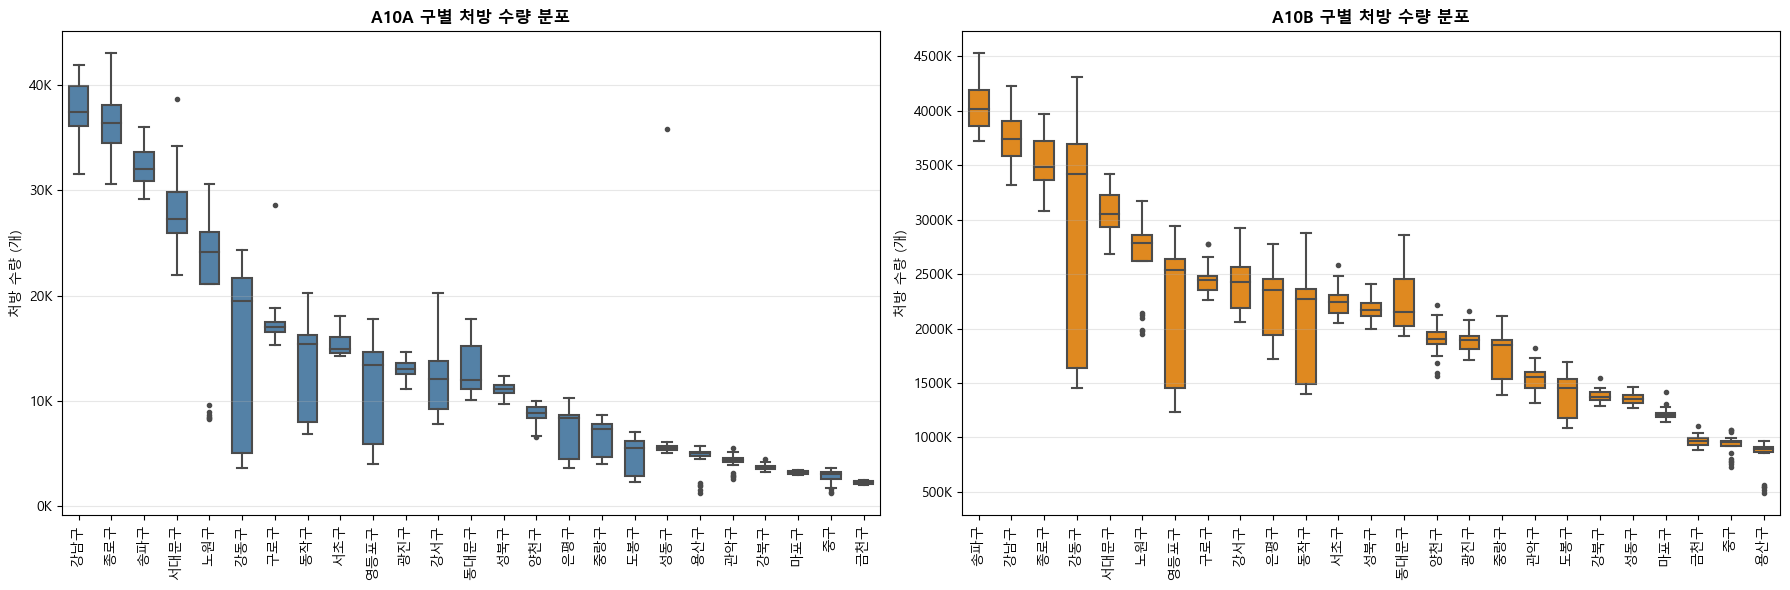

저장: output/figures/07_boxplot_by_gu.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, drug, color in zip(axes, ['A10A','A10B'], ['steelblue','darkorange']):
    data = df_master[df_master['약물구분'] == drug]
    order = data.groupby('시군구명칭')['수량'].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x='시군구명칭', y='수량', order=order,
                color=color, width=0.6, ax=ax, flierprops=dict(marker='o', markersize=3))
    ax.set_title(f'{drug} 구별 처방 수량 분포', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('처방 수량 (개)')
    ax.tick_params(axis='x', rotation=90)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/07_boxplot_by_gu.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 9. 구별 월평균 1인당 처방량 비교

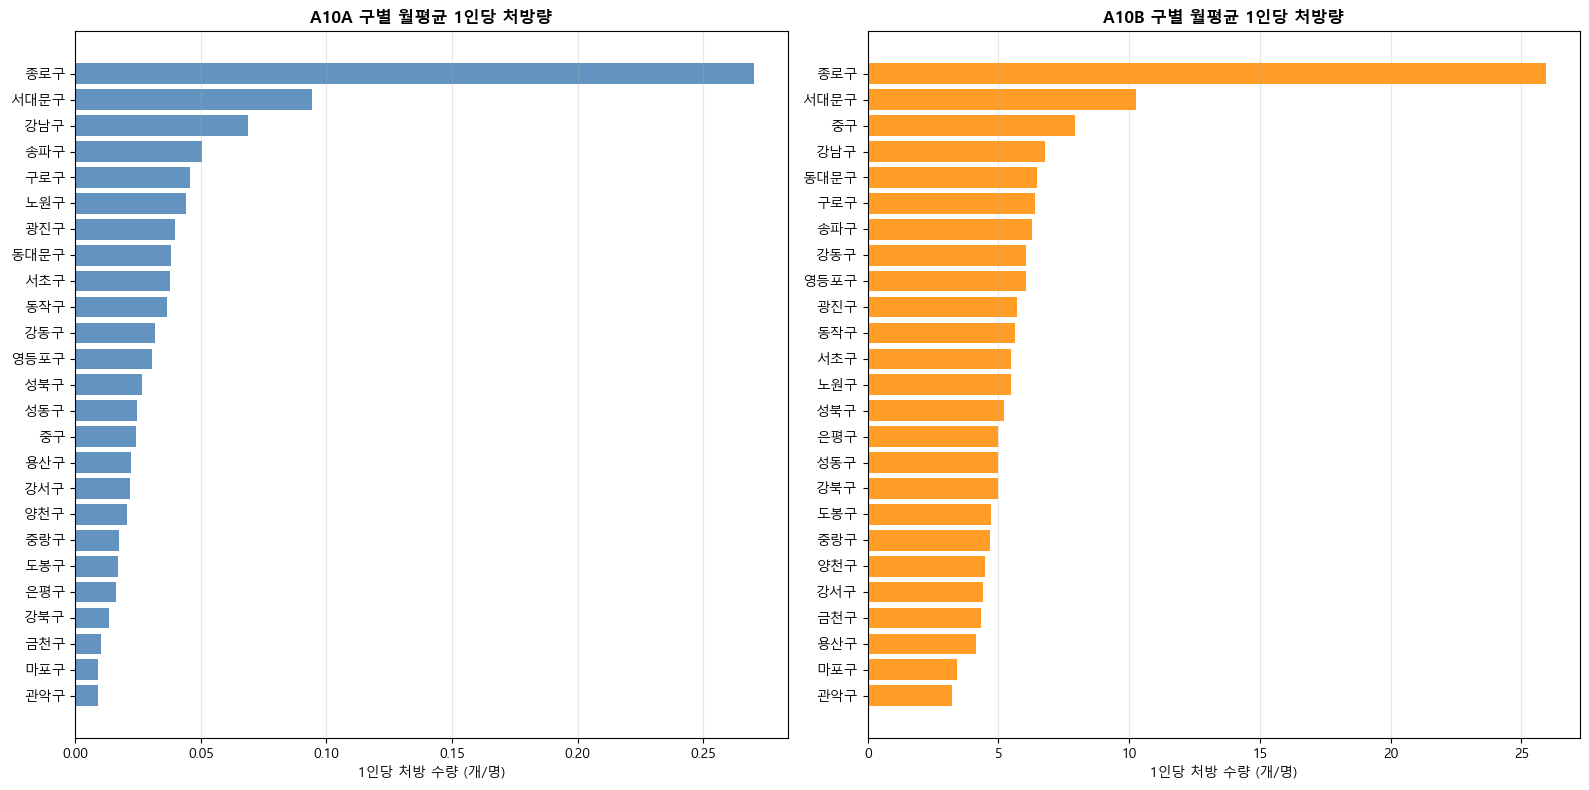

저장: output/figures/08_per_capita_by_gu.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, drug, color in zip(axes, ['A10A','A10B'], ['steelblue','darkorange']):
    data = df_master[df_master['약물구분'] == drug]
    means = data.groupby('시군구명칭')['처방량_per_capita'].mean().sort_values(ascending=False)
    ax.barh(means.index[::-1], means.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'{drug} 구별 월평균 1인당 처방량', fontsize=12, fontweight='bold')
    ax.set_xlabel('1인당 처방 수량 (개/명)')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/08_per_capita_by_gu.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 10. 최종 마스터 데이터셋 저장 및 검증

In [11]:
out_path = f'{OUT_DATA}/merged_master.csv'
df_master.to_csv(out_path, index=False, encoding='utf-8-sig')

print('=' * 50)
print('마스터 데이터셋 최종 검증')
print('=' * 50)
print(f'shape         : {df_master.shape}')
print(f'기간 범위     : {df_master["기간_dt"].min().strftime("%Y-%m")} ~ {df_master["기간_dt"].max().strftime("%Y-%m")}')
print(f'시군구 수     : {df_master["시군구명칭"].nunique()}')
print(f'약물구분      : {df_master["약물구분"].unique().tolist()}')
print(f'결측치 합계   : {df_master.isnull().sum().sum()}')
print(f'저장 경로     : {out_path}')
print()
missing = df_master.isnull().sum()
missing = missing[missing > 0]
print('컬럼별 결측치:', '없음' if len(missing) == 0 else '')
if len(missing): print(missing)
print()
print('기본 통계:')
display(df_master[['수량','금액','처방량_per_capita','총거주자수','고령인구비율']].describe().round(2))

마스터 데이터셋 최종 검증
shape         : (1250, 31)
기간 범위     : 2023-10 ~ 2025-10
시군구 수     : 25
약물구분      : ['A10A', 'A10B']
결측치 합계   : 0
저장 경로     : output/data/merged_master.csv

컬럼별 결측치: 없음

기본 통계:


,수량,금액,처방량_per_capita,총거주자수,고령인구비율
count,1250.00,1.250000e+03,1250.00,1250.00,1250.00
mean,1072176.93,5.096208e+08,3.18,369851.04,0.28
std,1235182.94,4.212142e+08,4.39,125212.53,0.03
min,1300.00,1.963795e+07,0.01,116927.00,0.23
25%,10131.50,1.593098e+08,0.03,298454.00,0.26
50%,267665.00,4.324241e+08,1.39,370618.00,0.27
75%,2050778.25,7.825790e+08,5.29,453875.00,0.30
max,4525880.00,1.937578e+09,29.25,640819.00,0.35
